# Group Project — World Happiness Report
## Research Methods for Business Analytics

**Dataset:** World Happiness Report  
**Course:** Research Methods for Business Analytics  
**Group:** TXA - A17

**Group Members:**
- 82715, Fabio Barbagallo
- 81204, Fabrice Keraudren
- 81245, Giacomo Aleotti

## Table of Contents

1. [Project Overview](#1.-project-overview)
2. [Executive Summary](#2.-executive-summary)
3. [Introduction](#3.-introduction)
   - 3.1 [Data Source and Importing](#3.1-data-source-and-importing)
   - 3.2 [Variable Definitions](#3.2-variable-definitions)
4. [Data Cleaning](#4-data-cleaning)
   - 4.1 [Standardizing Column Names and Combining Datasets](#41-standardizing-column-names-and-combining-datasets)
   - 4.2 [Country Coverage](#42-country-coverage)
   - 4.3 [Missing Values](#43-missing-values)
   - 4.4 [Duplicates](#44-duplicates)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
   - 5.1 [Types of Variables](#51-types-of-variables)
   - 5.2 [Descriptive Statistics](#52-descriptive-statistics)
     - 5.2.1 [Frequencies](#521-frequencies)
     - 5.2.2 [Central Tendency and Spread](#522-central-tendency-and-spread)
     - 5.2.3 [Distribution and Extreme Values](#523-distribution-and-extreme-values)
     - 5.2.4 [Summary Statistics Table](#524-summary-statistics-table)
   - 5.3 [Relationships between Variables](#53-relationships-between-variables)
     - 5.3.1 [Scatterplots](#531-scatterplots)
     - 5.3.2 [Covariance](#532-covariance)
     - 5.3.3 [Pearson and Spearman Correlations](#533-pearson-and-spearman-correlations)
     - 5.3.4 [Correlation Heatmap](#534-correlation-heatmap)
     - 5.3.5 [Regional Patterns](#535-regional-patterns)
   - 5.4 [Patterns across Reports](#54-patterns-across-reports)
     - 5.4.1 [Matched 2015–2019 Subset](#541-matched-20152019-subset)
     - 5.4.2 [Distribution of Happiness Change](#542-distribution-of-happiness-change)
     - 5.4.3 [Geographic Distribution of Happiness Change](#543-geographic-distribution-of-happiness-change)
   - 5.5 [Constructed Variables for Hypothesis Testing](#55-constructed-variables-for-hypothesis-testing)
     - 5.5.1 [Merging with Outcome Variable](#551-merging-with-outcome-variable)
     - 5.5.2 [Descriptive Statistics of Constructed Variables](#552-descriptive-statistics-of-constructed-variables)
     - 5.5.3 [Summary and Next Steps](#553-summary-and-next-steps)
6. [Research Question and Hypotheses](#6-research-question-and-hypotheses)
   - 6.1 [Research Question](#61-research-question)
   - 6.2 [Hypotheses](#62-hypotheses)
7. [Method 1: XXXX]
8. [Method 2: XXXX]
9. [Interpretation, Conclusion and Limitations](#9-interpretation-conclusion-and-limitations)
10. [Reflection on the use of AI](#10-reflection-on-the-use-of-ai)
11. [References](#11-references)

## 1. Project Overview

The goal of this project is to apply statistical methods from the Research Methods for Business Analytics course to a real-world dataset.

We use the World Happiness Report dataset (https://www.kaggle.com/datasets/unsdsn/world-happiness), covering the 2015–2019 report editions, to investigate patterns and differences in national happiness and their relationship with the factors used in the World Happiness Report framework.

The project will:

1. explore and understand the dataset,
2. clean and prepare the data for analysis,
3. perform exploratory data analysis,
4. formulate a research question and testable hypotheses based on the exploratory findings,
5. test the hypotheses using two different statistical methods,
6. interpret the results, and
7. discuss limitations and possible improvements.

The final research question and statistical methods will be selected after the initial exploratory analysis of the dataset.

## 2. Executive Summary

XXXXXXXXXXXXXXXXXXXXXXx
This section will summarize the main research question, methods, key findings, and conclusions of the project once the statistical analysis has been completed.

The final executive summary will briefly cover:

the objective of the study,
the main characteristics of the World Happiness dataset,
the research question and hypotheses,
the statistical methods used,
the most important results, and
the main conclusions and limitations.
XXXXXXXXXXXXXXXXXXXXXXx


## 3. Introduction

Happiness and life satisfaction differ considerably across countries and may be related to a range of economic, social, health, and institutional conditions. The World Happiness Report provides international data on people's evaluations of their lives and is widely used to compare well-being across countries.

This project uses data from the 2015–2019 editions of the World Happiness Report. The central outcome variable is the happiness_score, which is based on the Cantril Ladder, where respondents evaluate their current life on a scale from 0 (worst possible life) to 10 (best possible life).

The dataset also contains six factors used by the World Happiness Report to explain differences in national life evaluations: economic conditions, social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption. Importantly, the values provided for these factors in the Kaggle dataset are model-derived contributions to explaining the happiness score, rather than simple raw measurements of the underlying variables.

The 2015–2019 files represent different editions of the World Happiness Report rather than independent observations from single calendar years. The reported country scores are generally based on multi-year averages, which must be considered when analysing changes over time.

Before defining the final research question and hypotheses, we first explore and prepare the dataset to understand its structure, variables, country coverage, missing values, distributions, and patterns over time.

### 3.1 Data Source and Importing

The dataset (available on Kaggle: https://www.kaggle.com/datasets/unsdsn/world-happiness) contains separate CSV files for the 2015–2019 World Happiness Report editions. Each file contains country-level happiness scores together with several factors used in the World Happiness Report framework.

Because the column names and dataset structure differ across report editions, we first import the five files separately and inspect their column names before combining them into a consistent dataset.

In [120]:
import pandas as pd

# import the 5 report editions individually
df_2015 = pd.read_csv("data/2015.csv")
df_2016 = pd.read_csv("data/2016.csv")
df_2017 = pd.read_csv("data/2017.csv")
df_2018 = pd.read_csv("data/2018.csv")
df_2019 = pd.read_csv("data/2019.csv")

# print the column names for each dataset
print("2015:", df_2015.columns.tolist())
print("2016:", df_2016.columns.tolist())
print("2017:", df_2017.columns.tolist())
print("2018:", df_2018.columns.tolist())
print("2019:", df_2019.columns.tolist())

2015: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social sup

### 3.2 Variable Definitions

The World Happiness Report datasets contain national happiness scores and several factors used to explain differences in life evaluations across countries. As the available columns differ slightly across report editions, variable names were harmonised for this study. Importantly, the six explanatory variables in the Kaggle dataset represent estimated factor contributions rather than raw measurements of the underlying characteristics.

- year: Added manually and refers to the World Happiness Report edition (2015–2019). It does not necessarily represent a single measurement year, as happiness scores are generally based on multi-year survey averages.
- country: Country or territory included in the respective World Happiness Report.
- happiness_score: Main outcome variable. It represents the average national life evaluation based on the Gallup World Poll's Cantril Ladder, ranging from 0 (worst possible life) to 10 (best possible life).
- happiness_rank: A country's relative position within the respective report edition based on its happiness score. The happiness score is preferred for statistical analysis because ranks do not represent equal numerical differences.

The following six variables represent the estimated contribution of each factor to explaining why a country's life evaluation is higher than that of the hypothetical benchmark country, Dystopia:

- gdp_per_capita: Economic contribution, based on log GDP per capita adjusted for purchasing power differences.
- social_support: Contribution of social support, based on whether respondents have relatives or friends they can rely on in times of trouble.
- healthy_life_expectancy: Contribution of healthy life expectancy at birth.
- freedom: Contribution of satisfaction with the perceived freedom to make important life choices.
- generosity: Contribution of generosity, based on reported charitable donations adjusted for GDP per capita.
- corruption_perception: Contribution associated with lower perceived corruption in government and business. Higher values therefore indicate a more favourable contribution from this factor.

These contributions help explain differences in national life evaluations but do not directly determine or generate the observed happiness score.

## 4. Data Cleaning

The goal of this section is to prepare the initial combined dataset for further exploratory analysis steps as well as the statistical analyses.

### 4.1 Standardizing Column Names and Combining Datasets

The five yearly datasets use slightly different column names and structures. To analyse them together, we first harmonize the names of the variables that are available across all five editions.

We then add a 'year' variable for every observation indicating the respective World Happiness Report edition and combine the five datasets into one dataset.

In [121]:
# create a mapping of the columnn names to a single unified convention
column_map = {
    "Country": "country",
    "Country or region": "country",

    "Region": "region",

    "Happiness Rank": "happiness_rank",
    "Happiness.Rank": "happiness_rank",
    "Overall rank": "happiness_rank",

    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",

    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",

    "Family": "social_support",
    "Social support": "social_support",

    "Health (Life Expectancy)": "healthy_life_expectancy",
    "Health..Life.Expectancy.": "healthy_life_expectancy",
    "Healthy life expectancy": "healthy_life_expectancy",

    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",

    "Trust (Government Corruption)": "corruption_perception",
    "Trust..Government.Corruption.": "corruption_perception",
    "Perceptions of corruption": "corruption_perception",

    "Generosity": "generosity"
}

# rename all the columns in the datasets
df_2015 = df_2015.rename(columns=column_map)
df_2016 = df_2016.rename(columns=column_map)
df_2017 = df_2017.rename(columns=column_map)
df_2018 = df_2018.rename(columns=column_map)
df_2019 = df_2019.rename(columns=column_map)

# add an empty region column for the datasets (2017, 2018, 2019) where region is not available
for dataset in [df_2015, df_2016, df_2017, df_2018, df_2019]:
    if "region" not in dataset.columns:
        dataset["region"] = pd.NA

# the identified common columns are the following
common_columns = [
    "year", # identifies the year of the report
    "country",
    "region",
    "happiness_rank",
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "corruption_perception",
    "generosity"
]

# add the column year for each dataset as seperate column "year"
df_2015["year"] = 2015
df_2016["year"] = 2016
df_2017["year"] = 2017
df_2018["year"] = 2018
df_2019["year"] = 2019

# putting all the datasets together into one dataset
df = pd.concat([
    df_2015[common_columns],
    df_2016[common_columns],
    df_2017[common_columns],
    df_2018[common_columns],
    df_2019[common_columns]
], ignore_index=True)

# print the shape (number of rows and columns) of df
print("Shape:", df.shape)

# print the first 5 rows of the combined dataset
df.head()

Shape: (782, 11)


,year,country,region,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
0,2015,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,2015,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,2015,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,2015,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,2015,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [122]:
# display the data types of each column in the combined dataset
df.dtypes

year                         int64
country                        str
region                      object
happiness_rank               int64
happiness_score            float64
gdp_per_capita             float64
social_support             float64
healthy_life_expectancy    float64
freedom                    float64
corruption_perception      float64
generosity                 float64
dtype: object

### 4.2 Country Coverage

The combined dataset contains observations from reports, but not all countries are included in every edition. Also, some inconsistencies  exist in the country naming conventions across different years (e.g., "Hong Kong" vs "Hong Kong S.A.R., China"). We therefore standardize country names before examining country coverage. We also use the region information available in the earlier report editions (2015-2016) to assign a consistent region to countries in later editions (2017-2019).

In [123]:
# number of observations in each report
df["year"].value_counts().sort_index()

year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64

In [124]:
# get the country names and remove any leading or trailing whitespaces
df["country"] = df["country"].str.strip() 

# check in which report editions each country name appears
years_per_country = df.groupby("country")["year"].apply(list) 

# identify country names that do not appear in all five report editions
incomplete = years_per_country[years_per_country.apply(len) < 5] 

print("distinct countries before harmonization:", df["country"].nunique())
print("Country names not present in all five editions:", len(incomplete), "\n")
print(incomplete.to_string())

distinct countries before harmonization: 170
Country names not present in all five editions: 29 

country
Angola                      [2015, 2016, 2017, 2018]
Belize                            [2016, 2017, 2018]
Central African Republic    [2015, 2017, 2018, 2019]
Comoros                           [2015, 2016, 2019]
Djibouti                                      [2015]
Gambia                                        [2019]
Hong Kong                   [2015, 2016, 2018, 2019]
Hong Kong S.A.R., China                       [2017]
Laos                        [2015, 2016, 2018, 2019]
Lesotho                     [2015, 2017, 2018, 2019]
Macedonia                   [2015, 2016, 2017, 2018]
Mozambique                  [2015, 2017, 2018, 2019]
Namibia                     [2016, 2017, 2018, 2019]
North Cyprus                      [2015, 2016, 2017]
North Macedonia                               [2019]
Northern Cyprus                         [2018, 2019]
Oman                                          

some countries appear twice in this list, because the naming is inconsistent across the years. We will standardize this in the following step.

In [125]:
# map each alternative spelling to one standard name
country_names = {
    "Hong Kong S.A.R., China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "North Cyprus": "Northern Cyprus",
    "Macedonia": "North Macedonia",
    "Somaliland region": "Somalia",
    "Somaliland Region": "Somalia",
    "Ivory Coast": "Cote d'Ivoire",
}
# overwrite the country names with the standardized names
df["country"] = df["country"].replace(country_names)

In [126]:
# check the country coverage again after standardizing the country names
years_per_country = df.groupby("country")["year"].nunique()

# countries that are not present in all five report editions
incomplete = years_per_country[years_per_country < 5]

print("Distinct countries after standardization:", df["country"].nunique())
print("Countries present in all five years:", (years_per_country == 5).sum())
print("Countries not present in all five years:", len(incomplete))

# check: standardizing names must not create duplicates
print("Duplicated country-year pairs:", df.duplicated(subset=["country", "year"]).sum())

Distinct countries after standardization: 163
Countries present in all five years: 147
Countries not present in all five years: 16
Duplicated country-year pairs: 1


In [127]:
# show countries that are not present in all five report editions
print(incomplete.sort_values())

country
Gambia                      1
Djibouti                    1
Oman                        1
Puerto Rico                 1
Swaziland                   2
Suriname                    2
Belize                      3
Comoros                     3
Lesotho                     4
Laos                        4
Angola                      4
Central African Republic    4
Mozambique                  4
Namibia                     4
Sudan                       4
South Sudan                 4
Name: year, dtype: int64


Now that we have harmonized the country names and do not have any duplicates, we will continue by assigning regions to later report editions using the region information available in the 2015 and 2016 datasets. Finally, we will check the country coverage for the combined dataset.

In [128]:
# create a country-region lookup from observations where region is available
region_map = (
    df.dropna(subset=["region"])
      .drop_duplicates(subset="country")
      .set_index("country")["region"]
)

# fill missing region values using the country-region lookup
df["region"] = df["region"].fillna(df["country"].map(region_map))

In [129]:
# check whether any countries still have no region assigned
missing_regions = df.loc[df["region"].isna(), "country"].unique()

print("Countries without region:", len(missing_regions))
print(missing_regions)

Countries without region: 1
<StringArray>
['Gambia']
Length: 1, dtype: str


In [130]:
# Gambia has no assigned region from a previous report edition, therefore we will manually assign it to the "Sub-Saharan Africa" region
df.loc[df["country"] == "Gambia", "region"] = "Sub-Saharan Africa"

Now, we can print the final Country Coverage statistics

In [131]:
# final country coverage summary
years_per_country = df.groupby("country")["year"].nunique()

print("Total unique countries:", df["country"].nunique())
print("Countries present in all five report editions:", (years_per_country == 5).sum())
print("Countries not present in all five report editions:", (years_per_country < 5).sum())
print("Duplicated country-year pairs:", df.duplicated(subset=["country", "year"]).sum())
print("Missing regions:", df["region"].isna().sum())

print("\nUnique countries per region:")
print(df.groupby("region")["country"].nunique().sort_values(ascending=False))

Total unique countries: 163
Countries present in all five report editions: 147
Countries not present in all five report editions: 16
Duplicated country-year pairs: 1
Missing regions: 0

Unique countries per region:
region
Sub-Saharan Africa                 43
Central and Eastern Europe         29
Latin America and Caribbean        24
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
Australia and New Zealand           2
North America                       2
Name: country, dtype: int64


After standardizing country names, the dataset contains 164 unique countries, of which 146 appear in all five report editions. The remaining 18 countries are retained and can be filtered later if required.

No duplicated country-year observations remain, and all observations have been assigned to one of the World Happiness Report regions.

### 4.3 Missing Values

Before further analyzing the variables in descriptive statistics, we check whether the combined dataset contains missing values. Missing observations are important because they may affect which variables can be used in the later statistical analysis.

In [132]:
# check the number of missing values for each variable
df.isna().sum()

year                       0
country                    0
region                     0
happiness_rank             0
happiness_score            0
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
corruption_perception      1
generosity                 0
dtype: int64

In [133]:
# identify which observation contains the missing value
df[df.isna().any(axis=1)]

,year,country,region,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
489,2018,United Arab Emirates,Middle East and Northern Africa,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186


The dataset contains one missing value for the corruption_perception for the UAE in the 2018 report.

Based on the available dataset, we cannot determine why this value is missing or classify the mechanism as MCAR, MAR, or MNAR. It may be MNAR (Missing Not At Random), because the government of the UAE did not want to publish the data for this metric in that year. 

Since only one observation is affected, we leave the value as missing rather than estimating it (e.g. using interpolation of the neighbouring years, or using the mean). It is methodologically cleaner to omit this value later if the statistical methods require it, instead of trying to artifically impute it.

In [134]:
# show the missing value in the timeline
uae = df[df["country"] == "United Arab Emirates"]
print(uae[["country", "year", "corruption_perception"]].to_string(index=False))

             country  year  corruption_perception
United Arab Emirates  2015                0.38583
United Arab Emirates  2016                0.35561
United Arab Emirates  2017                0.32449
United Arab Emirates  2018                    NaN
United Arab Emirates  2019                0.18200


### 4.4 Duplicates

After standardizing the country names, we check whether the combined dataset contains duplicated rows or multiple observations for the same country within the same report. Such duplicates could bias later summary statistics and statistical analyses.

In [135]:
# completely identical rows
print("Identical rows               :", df.duplicated().sum())

# the same country more than once in the same year
print("Duplicated country-year pairs:", df.duplicated(subset=["country", "year"]).sum())

Identical rows               : 0
Duplicated country-year pairs: 1


No duplicated rows or duplicated country-year observations were found. Each country therefore appears at most once within each report edition.

## 5. Exploratory Data Analysis

We now explore the cleaned dataset to understand its variable types, distributions, summary statistics, relationships & correlations, and patterns across the reports before defining the research question and hypotheses.

### 5.1 Types of Variables

Our dataset contains both categorical and continuous variables. Understanding the measurement scale of each variable is essential for selecting appropriate statistical methods.

**Categorical Variables:** 
- `country`: nominal categorical variable identifying country or territory
- `region`: nominal categorical variable identifying the world region of the country

**Ordinal and Temporal Variables:**
- `year`: (ordered) discrete temporal variable, identifying the report edition. Depending on the analysis, it can be treated as an ordered factor or as a numeric time variable.
- `happiness_rank`: ordinal variable representing a country's relative position within a report year. Differences between ranks do not represent equal differences in happiness.

**Continuous Variables:**
- `happiness_score`: continuous variable representing average national life evaluation.
- `gdp_per_capita`, `social_support`, `healthy_life_expectancy`, `freedom`, `corruption_perception`, and `generosity` are continuous numerical variables. As explained previously, they represent estimated factor contributions rather than raw measurements of the underlying characteristics.

For most statistical analyses, we therefore focus on happiness_score and the six continuous factor contributions rather than happiness_rank

### 5.2. Descriptive Statistics

#### 5.2.1 Frequencies

We first examine the frequency distributions of the categorical and discrete variables. Since country contains a large number of categories, frequency summaries are more informative for region and year.

In [136]:
# absolute frequencies
print("Observations per report edition:")
print(df["year"].value_counts().sort_index())

print("\nObservations per region:")
print(df["region"].value_counts())

Observations per report edition:
year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64

Observations per region:
region
Sub-Saharan Africa                 196
Central and Eastern Europe         145
Latin America and Caribbean        111
Western Europe                     105
Middle East and Northern Africa     96
Southeastern Asia                   44
Southern Asia                       35
Eastern Asia                        30
North America                       10
Australia and New Zealand           10
Name: count, dtype: int64


In [137]:
# relative frequencies in percent
print("Relative frequency by region (%):")
print((df["region"].value_counts(normalize=True) * 100).round(2))

Relative frequency by region (%):
region
Sub-Saharan Africa                 25.06
Central and Eastern Europe         18.54
Latin America and Caribbean        14.19
Western Europe                     13.43
Middle East and Northern Africa    12.28
Southeastern Asia                   5.63
Southern Asia                       4.48
Eastern Asia                        3.84
North America                       1.28
Australia and New Zealand           1.28
Name: proportion, dtype: float64


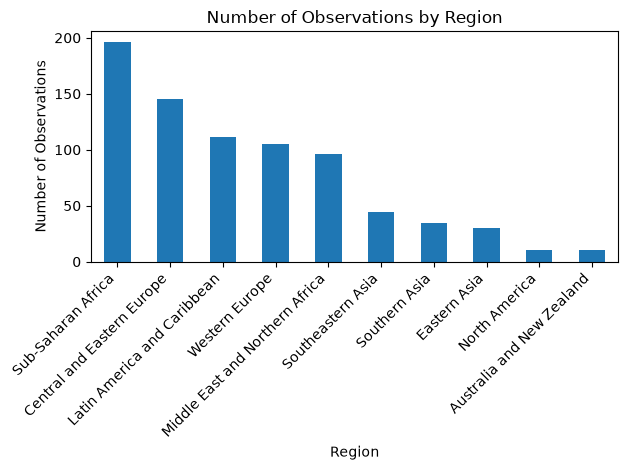

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# bar plot of observations per region
df["region"].value_counts().plot(kind="bar")

plt.title("Number of Observations by Region")
plt.xlabel("Region")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The regional frequencies are not evenly distributed. "Sub-Saharan Africa" contains the largest number of observations, while "North America" and "Australia and New Zealand" contain considerably fewer.

#### 5.2.2 Central Tendency and Spread

The descriptive statistics below display the mean, median (50th percentile), and standard deviation for each continuous variable. Also the minimum, maximuma and quartiles help us understand the spread of each variable in our dataset.

In [139]:
# continuous variables used in the analysis
continuous_variables = ["happiness_score", "gdp_per_capita", "social_support", "healthy_life_expectancy", "freedom", "corruption_perception", "generosity"]

# summary statistics for the continuous variables
df[continuous_variables].describe().round(3)

,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
count,782.000,782.000,782.000,782.000,782.000,781.000,782.000
mean,5.379,0.916,1.078,0.612,0.411,0.125,0.219
std,1.127,0.407,0.330,0.248,0.153,0.106,0.122
min,2.693,0.000,0.000,0.000,0.000,0.000,0.000
25%,4.510,0.606,0.869,0.440,0.310,0.054,0.130
50%,5.322,0.982,1.125,0.647,0.431,0.091,0.202
75%,6.190,1.236,1.327,0.808,0.531,0.156,0.279
max,7.769,2.096,1.644,1.141,0.724,0.552,0.838


In [140]:
# additional measures to show the spread
additional_statistics = pd.DataFrame({
    "variance": df[continuous_variables].var(),
    "min": df[continuous_variables].min(),
    "max": df[continuous_variables].max(),
    "range": df[continuous_variables].max() - df[continuous_variables].min()
})
additional_statistics.round(3)

,variance,min,max,range
happiness_score,1.271,2.693,7.769,5.076
gdp_per_capita,0.166,0.000,2.096,2.096
social_support,0.109,0.000,1.644,1.644
healthy_life_expectancy,0.062,0.000,1.141,1.141
freedom,0.023,0.000,0.724,0.724
corruption_perception,0.011,0.000,0.552,0.552
generosity,0.015,0.000,0.838,0.838


As we can see from the table, the average happiness score is 5.38 (SD = 1.13) and is close to the median of 5.32, while the six factor contributions vary considerably in their numerical ranges and should therefore not be compared directly based on absolute values.

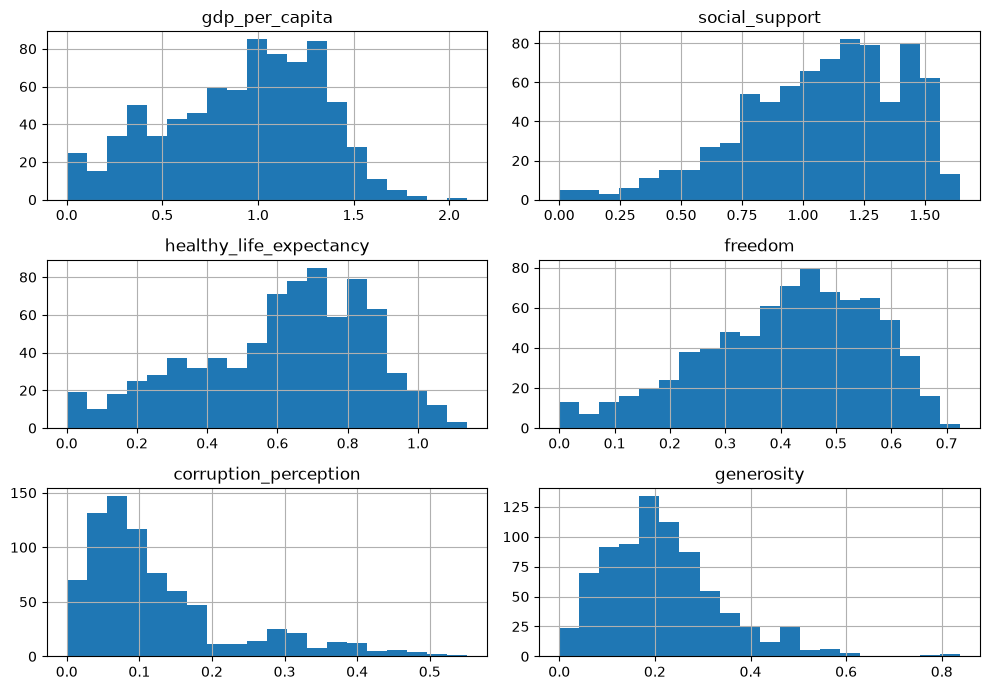

In [141]:
# distributions of the six factor contributions
factor_variables = ["gdp_per_capita","social_support","healthy_life_expectancy","freedom","corruption_perception","generosity"]

df[factor_variables].hist(figsize=(10, 7), bins=20)
plt.tight_layout()
plt.show()

The factor distributions differ noticeably in shape. GDP per capita, social support, healthy life expectancy, and freedom are relatively broadly distributed, whereas `corruption_perception` and `generosity` are more strongly concentrated at lower values with longer right tails. This is consistent with their higher positive skewness reported above.

#### 5.2.3 Distribution and Extreme Values

Next, we examine the distributions of the continuous variables and look for skewness and potential extreme values (ouliers). We begin with the happiness_score, which is the main outcome variable of the analysis.

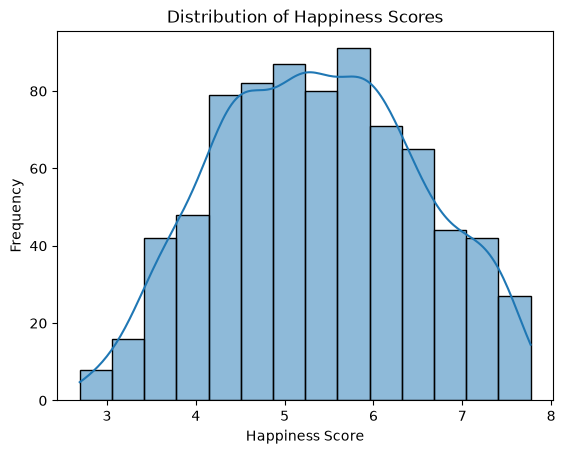

In [142]:
# distribution of happiness scores in histogram
sns.histplot(df["happiness_score"], kde=True)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

In [143]:
# skewness and kurtosis of the continuous variables
distribution_stats = pd.DataFrame({
    "skewness": df[continuous_variables].skew(),
    "kurtosis": df[continuous_variables].kurt()
})
distribution_stats.round(3)

,skewness,kurtosis
happiness_score,0.036,-0.761
gdp_per_capita,-0.319,-0.693
social_support,-0.685,0.158
healthy_life_expectancy,-0.501,-0.488
freedom,-0.521,-0.307
corruption_perception,1.521,1.880
generosity,1.044,2.020


Skewness measures asymmetry, so values close to **0** indicate a roughly symmetric distribution. As a  rule of thumb values between about **-0.5 and 0.5** are usually considered fairly symmetric, while values above **1** or below **-1** indicate clear skewness.

Kurtosis describes how heavy the tails of a distribution are compared with a normal distribution. Values close to **0** indicate a tail shape similar to normal, while positive values indicate heavier tails and more extreme observations.

In our data, `happiness_score` is almost perfectly symmetric (skewness = 0.036). Most other variables show only moderate skewness, while `corruption_perception` (1.521) and `generosity` (1.044) stand out as clearly positively skewed (asymmetric distribution). They also have relatively high positive kurtosis, suggesting heavier tails and more extreme high values than the other variables, as also seen in the boxplots below.

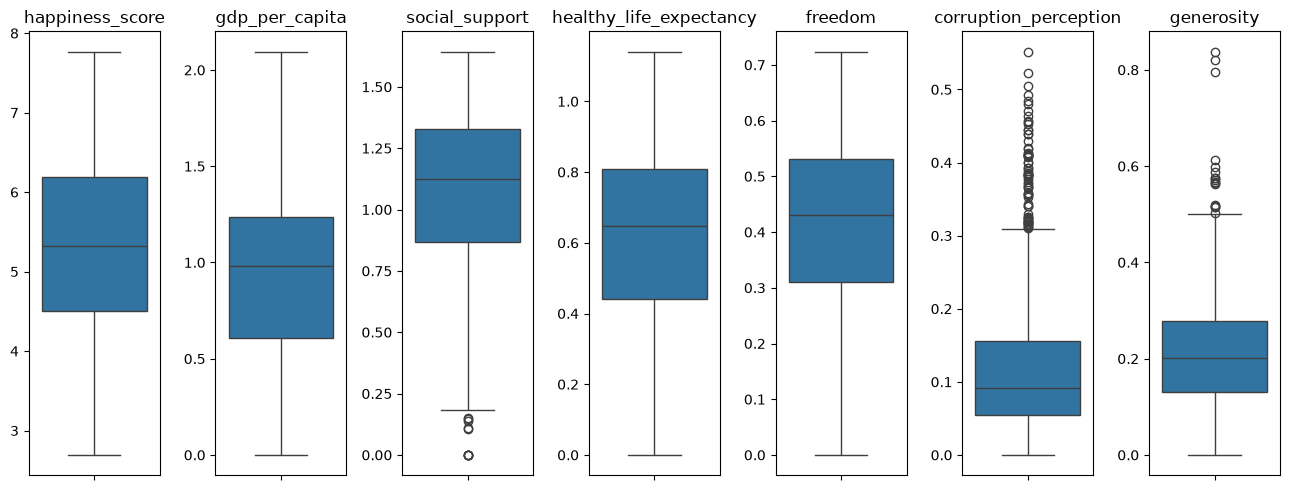

In [144]:
# one boxplot per variable
fig, axes = plt.subplots(1, 7, figsize=(13, 5))
for ax, variable in zip(axes, continuous_variables):
    sns.boxplot(y=df[variable], ax=ax)
    ax.set_title(variable)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

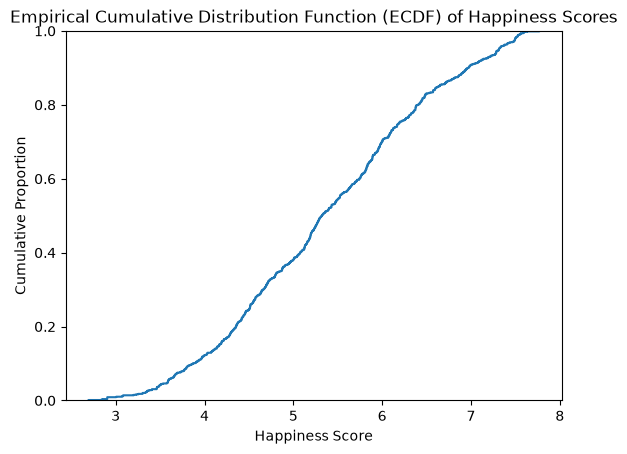

In [145]:
# empirical cumulative distribution of happiness scores
sns.ecdfplot(data=df, x="happiness_score")

plt.title("Empirical Cumulative Distribution Function (ECDF) of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Cumulative Proportion")
plt.show()

The ECDF shows the proportion of observations with a happiness score at or below a given value. For example, approximately 40% of observations have a happiness score of 5 or lower, while around 70% have a score of 6 or lower.

#### 5.2.4 Summary Statistics Table

Finally, we combine the most relevant descriptive statistics into one summary table to provide a compact overview.

In [146]:
# create a compact summary statistics table
summary_table = pd.DataFrame({
    "count": df[continuous_variables].count(),
    "mean": df[continuous_variables].mean(),
    "median": df[continuous_variables].median(),
    "std": df[continuous_variables].std(),
    "min": df[continuous_variables].min(),
    "max": df[continuous_variables].max(),
    "skewness": df[continuous_variables].skew(),
    "kurtosis": df[continuous_variables].kurt()
})

summary_table.round(3)

,count,mean,median,std,min,max,skewness,kurtosis
happiness_score,782,5.379,5.322,1.127,2.693,7.769,0.036,-0.761
gdp_per_capita,782,0.916,0.982,0.407,0.000,2.096,-0.319,-0.693
social_support,782,1.078,1.125,0.330,0.000,1.644,-0.685,0.158
healthy_life_expectancy,782,0.612,0.647,0.248,0.000,1.141,-0.501,-0.488
freedom,782,0.411,0.431,0.153,0.000,0.724,-0.521,-0.307
corruption_perception,781,0.125,0.091,0.106,0.000,0.552,1.521,1.880
generosity,782,0.219,0.202,0.122,0.000,0.838,1.044,2.020


Overall, the `happiness_score` is relatively symmetric and shows no obvious extreme outliers, while the six factor contributions differ considerably in scale and distribution. `corruption_perception` and `generosity` show the strongest positive skewness and heavier right tails.

### 5.3 Relationships between Variables

We now examine relationships between the variables. These analyses are exploratory because the factor variables are derived from the World Happiness Report's explanatory model, correlations with the happiness score should not be interpreted as independent causal evidence.

#### 5.3.1 Scatterplots

We use scatterplots to visually examine the direction and shape of the relationship between each factor contribution and the happiness score, and to identify possible non-linear patterns or extreme observations.

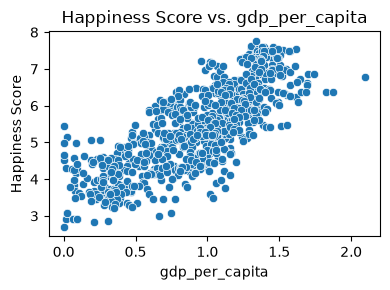

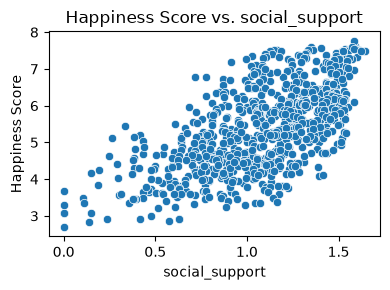

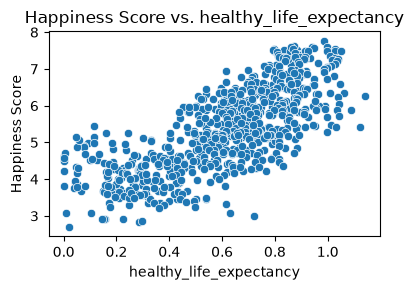

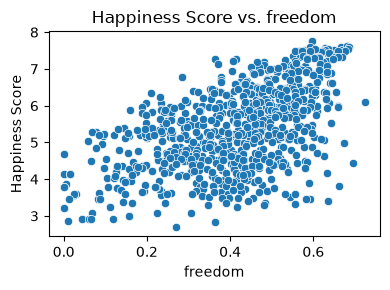

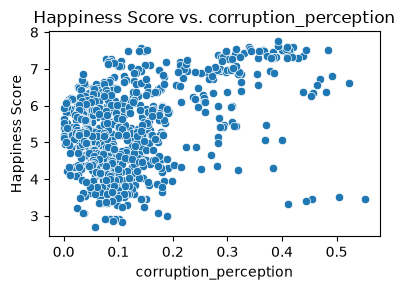

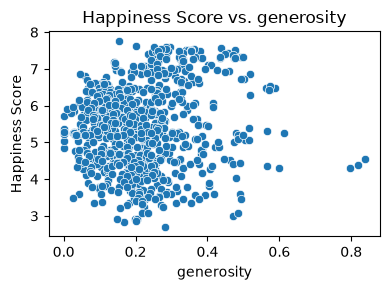

In [147]:
# scatterplots between happiness score and the six factor contributions
for variable in factor_variables:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(
        data=df, x=variable, y="happiness_score"
    )
    
    plt.title(f"Happiness Score vs. {variable}")
    plt.xlabel(variable)
    plt.ylabel("Happiness Score")
    plt.tight_layout()
    plt.show()

The scatterplots suggest clear positive relationships between `happiness_score` and GDP, social support, healthy life expectancy, and freedom.

The relationship with `corruption_perception` is also generally positive but shows more clustering and several unusual observations. `generosity` shows the weakest and least clearly linear relationship with happiness.

These patterns are exploratory and will not be interpreted causally because the six factor variables are model-derived contributions.

#### 5.3.2 Covariance

Covariance indicates whether two variables tend to move in the same or opposite direction. However, its magnitude depends on the scale of the variables, making it less suitable for comparing the strength of different relationships. We therefore use covariance mainly as a preliminary measure before examining standardized correlations.

In [148]:
# covariance between happiness score and the six factor contributions
covariances = df[continuous_variables].cov()["happiness_score"].drop("happiness_score")

covariances.round(3)

gdp_per_capita             0.362
social_support             0.241
healthy_life_expectancy    0.208
freedom                    0.095
corruption_perception      0.048
generosity                 0.019
Name: happiness_score, dtype: float64

All six factor contributions show positive covariance with `happiness_score`. However, because covariance depends on the measurement scales of the variables, the magnitudes should not be directly compared.

#### 5.3.3 Pearson and Spearman Correlations

We use correlation coefficients to compare the strength and direction of the relationships on a standardized scale. Pearson correlation measures linear relationships, while Spearman correlation is based on ranks and is less sensitive to skewness, outliers, and non-linear monotonic relationships.

In [149]:
# Pearson correlations with happiness score
pearson_corr = (
    df[continuous_variables].corr(method="pearson")["happiness_score"].drop("happiness_score")
)

# Spearman correlations with happiness score
spearman_corr = (
    df[continuous_variables].corr(method="spearman")["happiness_score"].drop("happiness_score")
)

# combine both measures into a table
correlation_table = pd.DataFrame({"Pearson": pearson_corr,"Spearman": spearman_corr})
correlation_table.round(3)

,Pearson,Spearman
gdp_per_capita,0.789,0.806
social_support,0.649,0.645
healthy_life_expectancy,0.742,0.762
freedom,0.551,0.542
corruption_perception,0.398,0.273
generosity,0.138,0.122


GDP per capita and healthy life expectancy show the strongest positive associations with `happiness_score` in both Pearson and Spearman correlations, followed by social support and freedom. 

Generosity shows only a weak relationship. Pearson and Spearman correlations are generally similar, suggesting that most relationships are reasonably monotonic. The largest difference occurs for `corruption_perception` (Pearson = 0.398; Spearman = 0.273), which is consistent with the clustering, skewness, and unusual observations visible in the scatterplot.

#### 5.3.4 Correlation Heatmap

The heatmap below confirms the positive associations between `happiness_score` and most factor contributions. It also shows substantial relationships between some of the factors themselves, particularly `gdp_per_capita` and `healthy_life_expectancy` (r = 0.78). In contrast, `generosity` is only weakly related to the other factors. This indicates that the six contributions do not represent completely independent dimensions.

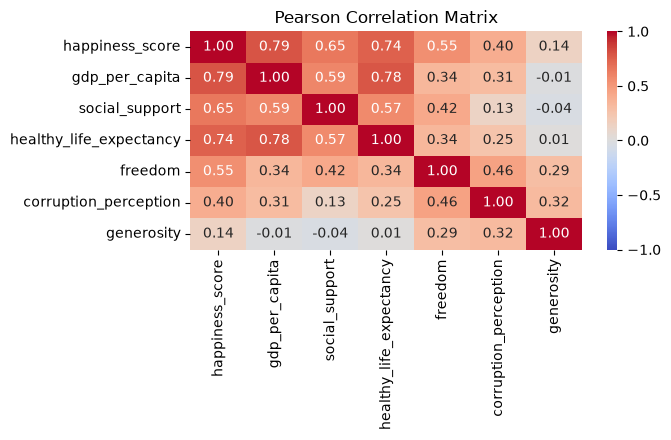

In [150]:
# Pearson correlation matrix
correlation_matrix = df[continuous_variables].corr(method="pearson")

plt.figure(figsize=(7, 4.5))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

#### 5.3.5 Regional Patterns

To explore differences in happiness across world regions, we compare happiness_score across regions using the 2019 report edition. Using a single report edition avoids counting the same country multiple times in this regional comparison.

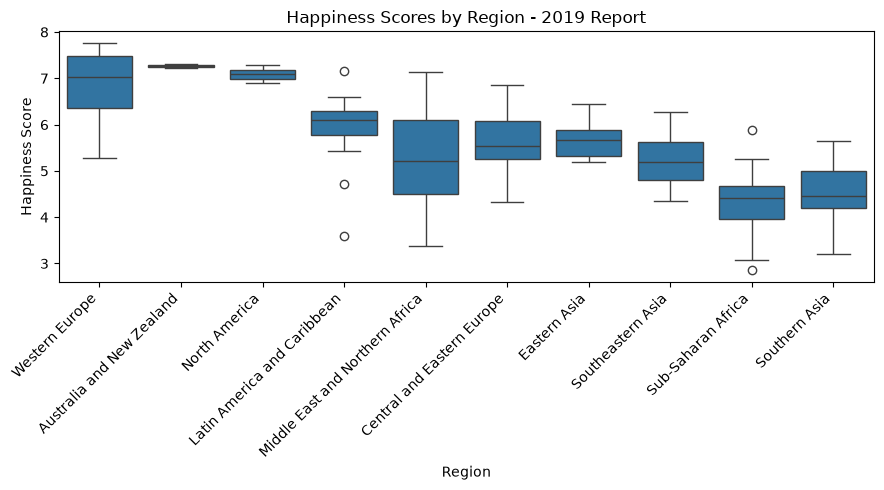

In [151]:
# use one report edition for the regional comparison
df_2019_region = df[df["year"] == 2019]

plt.figure(figsize=(9, 5))

sns.boxplot(data=df_2019_region,x="region",y="happiness_score")

plt.title("Happiness Scores by Region - 2019 Report")
plt.xlabel("Region")
plt.ylabel("Happiness Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The 2019 report shows clear regional differences in happiness scores. Western Europe, North America, and Australia and New Zealand have the highest scores, while Sub-Saharan Africa and Southern Asia tend to have lower scores. However, some regions contain only a small number of countries, so their distributions should be interpreted cautiously.

In [152]:
import plotly.express as px
import plotly.io as pio

# create a map of happiness scores for the 2019 report
df_2019_map = df[df["year"] == 2019].copy()

fig = px.choropleth(
    df_2019_map,
    locations="country",
    locationmode="country names",
    color="happiness_score",
    hover_name="country",
    hover_data={
        "region": True,
        "happiness_score": ":.3f",
    },
    color_continuous_scale="RdYlGn",
    range_color=(2.5, 8),
    title="Happiness Scores by Country - 2019 Report"
)

fig.update_geos(showframe=False,projection_type="natural earth")
fig.update_layout(width=1000,height=500,margin=dict(l=0, r=0, t=50, b=0),coloraxis_colorbar=dict(title="Happiness<br>Score"))
fig.show()

### 5.4 Patterns across Reports

Next, we explore how reported happiness scores differ across the five World Happiness Report editions from 2015 to 2019. These comparisons are descriptive because the report editions are based on overlapping multi-year survey periods rather than independent annual measurements.

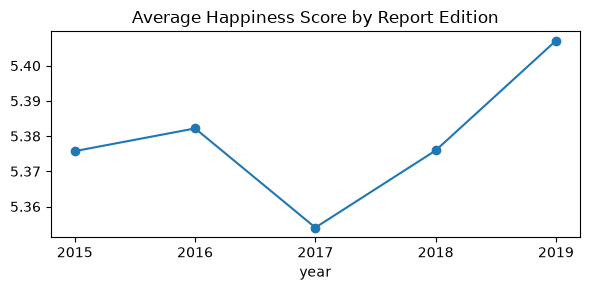

In [153]:
# average happiness score for every report edition
mean_happiness_by_year = (df.groupby("year")["happiness_score"].mean())

# plot the average happiness scores
plt.figure(figsize=(6, 3))
mean_happiness_by_year.plot(marker="o")

plt.title("Average Happiness Score by Report Edition")
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.tight_layout()
plt.show()

Average happiness scores remain relatively stable across the five report editions, ranging only from about 5.35 to 5.41. The 2017 edition has the lowest average and the 2019 edition the highest, but the differences are small and should not be interpreted as independent year-over-year changes because the underlying survey periods overlap.

#### 5.4.1 Matched 2015–2019 Subset

To examine changes in happiness over a longer period, we create a matched subset containing only countries that appear in both the 2015 and 2019 report editions. This results in 152 matched countries.

Then, we calculate the change in happiness score for each country as:
- **Happiness Change** = **Happiness Score 2019** - **Happiness Score 2015**

Positive values indicate a higher happiness score in the 2019 report, while negative values indicate a lower score.

In [154]:
# create a filtered dataset for countries present in both 2015 and 2019
scores_2015 = (df[df["year"] == 2015][["country", "region", "happiness_score"]].rename(columns={"happiness_score": "happiness_2015"}))
scores_2019 = (df[df["year"] == 2019][["country", "happiness_score"]].rename(columns={"happiness_score": "happiness_2019"}))
matched_2015_2019 = scores_2015.merge(scores_2019,on="country",how="inner")

print("Matched countries:", len(matched_2015_2019))

# print the first 5 rows of the matched dataset
matched_2015_2019.head()

Matched countries: 153


,country,region,happiness_2015,happiness_2019
0,Switzerland,Western Europe,7.587,7.480
1,Iceland,Western Europe,7.561,7.494
2,Denmark,Western Europe,7.527,7.600
3,Norway,Western Europe,7.522,7.554
4,Canada,North America,7.427,7.278


In [155]:
# change in happiness between the 2015 and 2019 report editions
matched_2015_2019["happiness_change"] = (matched_2015_2019["happiness_2019"] - matched_2015_2019["happiness_2015"])

#### 5.4.2 Distribution of Happiness Change

We now examine how much happiness scores changed between the 2015 and 2019 report editions within the matched subset of countries.

In [156]:
matched_2015_2019["happiness_change"].describe().round(3)

count    153.000
mean       0.054
std        0.506
min       -2.103
25%       -0.227
50%        0.023
75%        0.357
max        1.543
Name: happiness_change, dtype: float64

In [157]:
# count countries with positive, negative, or no change
change_counts = pd.Series({
    "Positive change": (matched_2015_2019["happiness_change"] > 0).sum(),
    "Negative change": (matched_2015_2019["happiness_change"] < 0).sum(),
    "No change": (matched_2015_2019["happiness_change"] == 0).sum()
})
change_counts

Positive change    80
Negative change    73
No change           0
dtype: int64

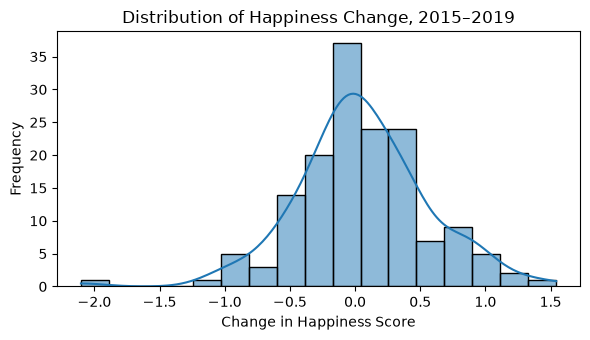

In [158]:
# plot a Histrogram of the delta of happiness scores between 2015 and 2019
plt.figure(figsize=(6, 3.5))
sns.histplot(matched_2015_2019["happiness_change"],kde=True)

plt.title("Distribution of Happiness Change, 2015–2019")
plt.xlabel("Change in Happiness Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The countries in the subset show only a small average increase in happiness between the 2015 and 2019 report editions (mean change = 0.057; median = 0.023). Of the 152 countries, about half (80 countries = 53%) show a positive change and the others (72 countries = 47%) a negative change. Most changes are concentrated close to zero, although a small number of countries show outlier increases or decreases.

In [159]:
# countries with the largest increases in happiness
largest_increases = (matched_2015_2019
    .sort_values("happiness_change", ascending=False)[["country", "region", "happiness_2015", "happiness_2019", "happiness_change"]]
    .head(8)
)
largest_increases

,country,region,happiness_2015,happiness_2019,happiness_change
149,Benin,Sub-Saharan Africa,3.340,4.883,1.543
145,Cote d'Ivoire,Sub-Saharan Africa,3.655,4.944,1.289
152,Togo,Sub-Saharan Africa,2.839,4.085,1.246
102,Honduras,Latin America and Caribbean,4.788,5.860,1.072
146,Burkina Faso,Sub-Saharan Africa,3.587,4.587,1.000
101,Hungary,Central and Eastern Europe,4.800,5.758,0.958
83,Romania,Central and Eastern Europe,5.124,6.070,0.946
137,Gabon,Sub-Saharan Africa,3.896,4.799,0.903


In [160]:
# countries with the largest decreases in happiness
largest_decreases = (matched_2015_2019
    .sort_values("happiness_change")[["country", "region", "happiness_2015", "happiness_2019", "happiness_change"]]
    .head(8)
)
largest_decreases

,country,region,happiness_2015,happiness_2019,happiness_change
21,Venezuela,Latin America and Caribbean,6.810,4.707,-2.103
94,Lesotho,Sub-Saharan Africa,4.898,3.802,-1.096
82,Zambia,Sub-Saharan Africa,5.129,4.107,-1.022
112,Zimbabwe,Sub-Saharan Africa,4.610,3.663,-0.947
115,Haiti,Latin America and Caribbean,4.518,3.597,-0.921
126,Malawi,Sub-Saharan Africa,4.292,3.410,-0.882
123,Botswana,Sub-Saharan Africa,4.332,3.488,-0.844
131,Yemen,Middle East and Northern Africa,4.077,3.380,-0.697


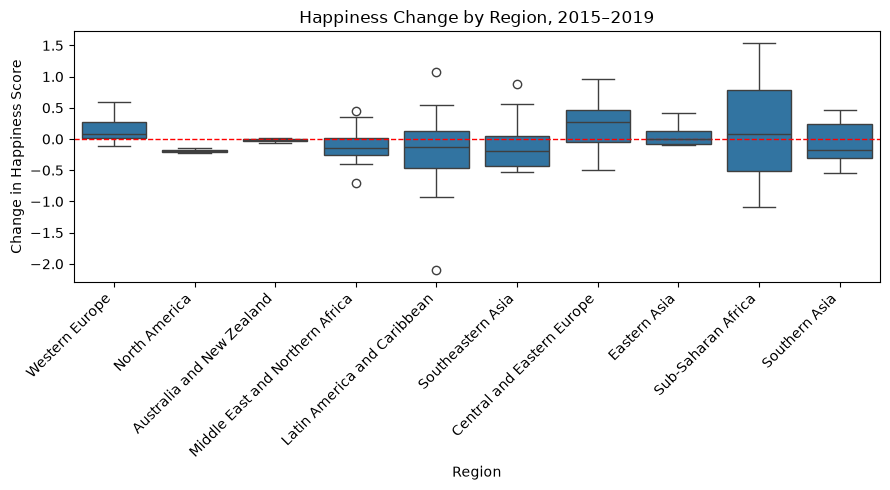

In [161]:
# boxplot of happiness change by region
plt.figure(figsize=(9, 5))
sns.boxplot(data=matched_2015_2019,x="region",y="happiness_change")
plt.axhline(0, color="red", linestyle="--", linewidth=1)

plt.title("Happiness Change by Region, 2015–2019")
plt.xlabel("Region")
plt.ylabel("Change in Happiness Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The countries with the largest changes help to explain the tails of the distribution. It seems that both the largest winners and loosers in terms of happiness are found in Sub-Saharan Africa, suggesting that this region is particularly extreme.

#### 5.4.3 Geographic Distribution of Happiness Change

As a final descriptive step, we visualize the geographic distribution of happiness change between the 2015 and 2019 report editions. This map helps identify whether increases and decreases are concentrated in particular parts of the world.

In [163]:
fig = px.choropleth(
    matched_2015_2019,
    locations="country",
    locationmode="country names",
    color="happiness_change",
    hover_name="country",
    hover_data={
        "region": True,
        "happiness_2015": ":.3f",
        "happiness_2019": ":.3f",
        "happiness_change": ":.3f",
    },
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    title="Geographic Distribution of Happiness Change, 2015–2019"
)

fig.update_geos(showframe=False, projection_type="natural earth")
fig.update_layout(width=1000,height=500,margin=dict(l=0, r=0, t=50, b=0),coloraxis_colorbar=dict(title="Change in<br>Happiness Score"))
fig.show()

### 5.5 Constructed Variables for Hypothesis Testing

To test the research hypotheses about factor balance and the weakest-link effect, we construct three new variables from the six factor contributions, each measured for the 2015 report edition.

The analysis focuses on the 2015 data because these measurements serve as predictors of subsequent changes in happiness between 2015 and 2019. The constructed variables are:

1. **Factor Balance** — A measure of how evenly distributed a country's factor contributions are across the six dimensions. Countries with balanced profiles have similar values across all factors, while unbalanced profiles show strong variation among factors. We measure this using the standard deviation of the six factors; lower SD indicates more balance.

2. **Weakest Factor** — The minimum value among the six factors. This captures the "bottleneck" or limiting factor in a country's happiness-support system.

3. **Overall Factor Level** — The mean value across all six factors. This serves as a control variable to isolate the effect of balance or the weakest factor, independent of the general strength of a country's factor profile.

In [ ]:
# Extract the 2015 data for constructing variables
df_2015_only = df[df["year"] == 2015].copy()

# Define the six factor variables
factor_cols = ["gdp_per_capita", "social_support", "healthy_life_expectancy", 
               "freedom", "corruption_perception", "generosity"]

# Calculate the three constructed variables
df_2015_only["factor_balance"] = df_2015_only[factor_cols].std(axis=1)
df_2015_only["weakest_factor"] = df_2015_only[factor_cols].min(axis=1)
df_2015_only["overall_factor_level"] = df_2015_only[factor_cols].mean(axis=1)

# Display the new variables for the first 10 countries
print("Constructed variables for the first 10 countries in 2015:")
print(df_2015_only[["country", "region", "factor_balance", "weakest_factor", "overall_factor_level"]].head(10))

#### 5.5.1 Merging with Outcome Variable

We now merge the constructed variables with the happiness change data to create the analysis dataset that will be used for hypothesis testing.

In [ ]:
# Create the final analysis dataset by merging 2015 predictors with 2015-2019 happiness change
analysis_data = df_2015_only[["country", "region", "happiness_score", "factor_balance", "weakest_factor", "overall_factor_level"]].copy()

# Merge with the happiness change variable
analysis_data = analysis_data.merge(
    matched_2015_2019[["country", "happiness_2019", "happiness_change"]], 
    on="country",
    how="inner"
)

print(f"Analysis dataset contains {len(analysis_data)} countries")
print("\nFirst 10 observations:")
print(analysis_data.head(10))

#### 5.5.2 Descriptive Statistics of Constructed Variables

We examine the distributions of the three newly constructed variables to understand their ranges and variation in the dataset.

In [ ]:
# Descriptive statistics for the constructed variables
constructed_vars = ["factor_balance", "weakest_factor", "overall_factor_level"]

print("Descriptive Statistics for Constructed Variables:")
print(analysis_data[constructed_vars].describe().round(4))

# Additional statistics
print("\n\nAdditional Statistics:")
additional_stats = pd.DataFrame({
    "variance": analysis_data[constructed_vars].var(),
    "skewness": analysis_data[constructed_vars].skew(),
    "kurtosis": analysis_data[constructed_vars].kurt()
})
print(additional_stats.round(4))

**Key Observations:**

- **Factor Balance** (mean = 0.352, SD = 0.125) varies considerably across countries, ranging from approximately 0.08 (highly balanced) to 0.76 (highly unbalanced). The positive skewness (0.85) indicates that most countries have relatively balanced factor profiles, with a tail of countries showing more imbalanced distributions.

- **Weakest Factor** (mean = 0.123, SD = 0.105) shows high positive skewness (1.43), indicating that most countries have at least one very weak factor contribution, with a smaller number of countries having stronger minimum factors. This pattern is consistent with the right-skewed distributions of `corruption_perception` and `generosity` observed in Section 5.2.3.

- **Overall Factor Level** (mean = 0.619, SD = 0.255) is approximately normally distributed (skewness = -0.11) and shows the largest variation (SD = 0.255) compared to the other constructed variables, reflecting substantial differences in countries' general factor strength.

In [ ]:
# Histograms of the three constructed variables
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, var in zip(axes, constructed_vars):
    sns.histplot(data=analysis_data, x=var, kde=True, ax=ax)
    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel(var)

plt.tight_layout()
plt.show()

#### 5.5.3 Summary and Next Steps

The constructed variables have been successfully created and merged with the outcome variable (happiness change from 2015 to 2019) to form the analysis dataset. The dataset now contains:

- **153 countries** with complete data for all variables
- **Three predictor variables** constructed from 2015 World Happiness Report data:
  - Factor Balance (SD of six factors)
  - Weakest Factor (minimum of six factors)
  - Overall Factor Level (mean of six factors)
- **One outcome variable**: happiness_change (2015→2019)

The descriptive statistics reveal:
- **Factor Balance** ranges from 0.08 to 0.76, with mean 0.352 and positive skewness, indicating most countries have relatively balanced profiles with some outliers showing stronger imbalance.
- **Weakest Factor** ranges from 0.00 to 0.48, with mean 0.123 and high positive skewness, reflecting that many countries have very weak performance in at least one dimension.
- **Overall Factor Level** ranges from 0.15 to 1.21, with mean 0.619 and near-normal distribution, showing substantial variation in countries' general factor strength.

This analysis dataset is now ready for formal hypothesis testing using regression methods in Method 1 and Method 2, where we will:
1. Test whether factor balance predicts happiness change (Hypothesis 1)
2. Test whether the weakest factor predicts happiness change after controlling for overall factor level (Hypothesis 2)
3. Verify statistical significance and check key assumptions of the regression models

In [ ]:
# Summary information about the analysis dataset
print("Analysis Dataset Summary:")
print(f"Number of countries: {len(analysis_data)}")
print(f"Number of variables: {len(analysis_data.columns)}")
print(f"\nVariables in analysis dataset:")
print(analysis_data.columns.tolist())
print(f"\nRegional distribution of analysis sample:")
print(analysis_data["region"].value_counts().sort_values(ascending=False))

## 6. Research Question and Hypotheses

### 6.1 Research Question

Based on the exploratory analysis, this project focuses on whether the profile of a country's configuration of happiness-contribution factors, rather than the strength of any single factor alone, is associated with subsequent changes in reported happiness.

- **Main Research Question: *Are subsequent changes (2015 to 2019) in national happiness associated with the configuration (both the balance and the weakest factor components) of a country’s happiness-support profile?***

Most straightforward analyses of the World Happiness Report focus on whether individual factors such as economic contribution, social support, health, or freedom are associated with happiness. However, these factors are already part of the World Happiness Report's explanatory framework. Instead of reproducing these known relationships, this study takes a different perspective by examining the configuration of the six factors as a system.

The analysis considers two related ideas. First, countries whose factors are relatively balanced may have a broader and potentially more resilient foundation for happiness than countries whose profiles are strongly concentrated in only a few dimensions. Second, even countries with relatively strong overall profiles may be constrained by one particularly weak dimension. This leads to a “weakest-link” perspective in which the lowest-performing factor may contain information about subsequent happiness development that is not captured by the overall average factor level.

An additional exploratory analysis examines whether the part of the happiness score not represented by the six factor contributions shows systematic regional patterns. This is used descriptively to investigate whether broader regional characteristics may be associated with differences not captured by the six-factor framework.

### 6.2 Hypotheses

**Hypothesis 1: Factor Balance**
- H₀-₁: There is no association between the balance of a country's six-factor contribution profile in the 2015 report and its change in happiness between the 2015 and 2019 reports.
- H₁-₁: Countries with **more balanced** factor-contribution profiles in the 2015 report **tend to experience more favourable changes in happiness** between the 2015 and 2019 reports.

This hypothesis tests whether the configuration of strengths across multiple dimensions is associated with subsequent happiness development, rather than focusing on the absolute level of any individual factor.

**Hypothesis 2: Weakest-Link Effect**
- H₀-₂: A country's weakest factor contribution in the 2015 report is not associated with its subsequent change in happiness once the overall level of its factor contributions is taken into account.
- H₁-₂: Countries with a **stronger weakest factor** in the 2015 report tend to experience **more favourable changes in happiness** between the 2015 and 2019 reports, even after differences in overall factor-contribution level are taken into account.

This hypothesis examines whether the lowest-performing dimension of a country may act as a limiting factor for subsequent happiness development. It therefore complements the balance hypothesis by testing whether the weakest part of a country's factor profile contains additional information beyond its general level of factor strength.

## 7. Method 1: XXXX

apply one method, test one hypothesis, explain why chosen, check key assumption, interpret results

## 8. Method 2: XXXX

apply one method, test one hypothesis, explain why chosen, check key assumption, interpret results

## 9. Interpretation, Conclusion and Limitations

text, findings, limitations, ways to improve

## 10. Reflection on the use of AI

which tools, for what tasks, how (prompt examples), what the team added beyond AI output

## 11. References

text